# **Практическая работа №4. Работа с векторными данными в GeoPandas**

Выполняя практическую работу, опирайтесь на теоритический материал, рассматриваемый на занятии:

- Использование NumPy, Pandas и GeoPandas для работы с пространственными данными: https://u.to/rk86Ig
- Ультимативный обзор аналитических инструментов GeoPandas:  https://u.to/s0d3Ig
- Теоретические аспекты и практические примеры получения векторных данных из OpenStreetMap: https://u.to/9SdwIQ

Дополнительно:

- Особенности построения интерактивных карт с помощью библиотеки Leafmap: https://u.to/WvA3Ig

Официальная техническая документацию по используемым библиотекам:

- **NumPy**: https://numpy.org/doc/stable/
- **Pandas**: https://pandas.pydata.org/docs/
- **GeoPandas**: https://geopandas.org/en/stable/docs.html
- **Leafmap**: https://leafmap.org/

In [1]:
%%capture
!pip install geopandas leafmap mapclassify # Устанавливаем библиотеку GeoPandas и необходимые зависимости

## **Задание №1. Операции с массивами NumPy и геопространственными координатами**


1. Создайте двумерный массив NumPy, содержащий широту и долготу следующих городов: Токио (35.6895, 139.6917), Нью-Йорк (40.7128, -74.0060), Лондон (51.5074, -0.1278) и Париж (48.8566, 2.3522).


In [2]:
import numpy as np

city_names = ["Токио", "Нью-Йорк", "Лондон", "Париж"]
coordinates = np.array([
    [35.6895, 139.6917],
    [40.7128, -74.0060],
    [51.5074, -0.1278],
    [48.8566, 2.3522]
])
coordinates

array([[ 3.568950e+01,  1.396917e+02],
       [ 4.071280e+01, -7.400600e+01],
       [ 5.150740e+01, -1.278000e-01],
       [ 4.885660e+01,  2.352200e+00]])

2. Преобразуйте значения широты и долготы из градусов в радианы с помощью функции np.radians().


In [3]:
coordinates_rad = np.radians(coordinates)
coordinates_rad

array([[ 6.22899283e-01,  2.43808010e+00],
       [ 7.10572408e-01, -1.29164837e+00],
       [ 8.98973719e-01, -2.23053078e-03],
       [ 8.52708531e-01,  4.10536347e-02]])



3. Рассчитайте поэлементную разницу между координатами Токио и других городов в радианах.

In [4]:
import pandas as pd

coordinate_differences = coordinates_rad[0] - coordinates_rad[1:]
pd.DataFrame(coordinate_differences, index=city_names[1:], columns=["Δ широты, рад", "Δ долготы, рад"])

,"Δ широты, рад","Δ долготы, рад"
Нью-Йорк,-0.087673,3.729728
Лондон,-0.276074,2.440311
Париж,-0.229809,2.397026


## **Задание 2. Операции с DataFrame Pandas и геопространственными данными**


1. Загрузите набор данных о городах мира по следующему URL с помощью Pandas: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv




```python
import pandas as pd
# Pandas поддерживает загрузку данных по прямым ссылкам из сети Интернет
url = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"

df = pd.read_csv(url)
```



In [5]:
url_cities = "https://github.com/opengeos/datasets/releases/download/world/world_cities.csv"
df = pd.read_csv(url_cities)
df.shape

(1249, 6)

2. Отобразите первые 5 строк и проверьте наличие отсутствующих значений.


In [6]:
display(df.head())
df.isna().sum()

,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


id            0
name          0
country       0
latitude      0
longitude     0
population    0
dtype: int64

3. Отфильтруйте набор данных, чтобы включить только города с населением более 1 миллиона человек.


In [7]:
large_cities = df[df["population"] > 1_000_000].copy()
print(f"Городов с населением более миллиона: {len(large_cities)}")
large_cities.head()

Городов с населением более миллиона: 392


,id,name,country,latitude,longitude,population
97,98,Turin,ITA,45.07039,7.66996,1652000
103,104,Lille,FRA,50.64997,3.08001,1044000
123,124,San Bernardino,USA,34.12038,-117.30003,1745000
124,125,Bridgeport,USA,41.17998,-73.19996,1018000
126,127,Manchester,GBR,53.50042,-2.24799,2230000


4. Сгруппируйте города по странам и рассчитайте общую численность населения для каждой страны.


In [8]:
country_population = (
    df.groupby("country", as_index=False)["population"]
    .sum()
    .sort_values("population", ascending=False)
)
country_population.head(10)

,country,population
34,CHN,217132049
188,USA,156465416
79,IND,154810226
25,BRA,80794236
88,JPN,65779390
149,RUS,47306359
114,MEX,44222027
78,IDN,27339158
136,PAK,26416033
129,NGA,24852791




5. Отсортируйте города по населению в порядке убывания и отобразите первые 10 городов.

In [9]:
df.sort_values("population", ascending=False).head(10)

,id,name,country,latitude,longitude,population
1239,1240,Tokyo,JPN,35.68502,139.75141,35676000
1224,1225,New York,USA,40.74998,-73.98002,19040000
1230,1231,Mexico City,MEX,19.44244,-99.13099,19028000
1240,1241,Mumbai,IND,19.01699,72.85699,18978000
1245,1246,Sao Paulo,BRA,-23.55868,-46.62502,18845000
1148,1149,Delhi,IND,28.66999,77.23000,15926000
1238,1239,Shanghai,CHN,31.21645,121.43650,14987000
1243,1244,Kolkata,IND,22.49497,88.32468,14787000
1175,1176,Dhaka,BGD,23.72306,90.40858,12797394
1217,1218,Buenos Aires,ARG,-34.60250,-58.39753,12795000


## **Задание №3. Создание и обработка GeoDataFrames с помощью GeoPandas**


1. Загрузите набор данных о зданиях Нью-Йорка из файла GeoJSON с помощью GeoPandas: https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson

In [10]:
import geopandas as gpd

url_buildings = "https://github.com/opengeos/datasets/releases/download/places/nyc_buildings.geojson"
buildings = gpd.read_file(url_buildings)
display(buildings.head())
print(f"Зданий: {len(buildings)}, CRS: {buildings.crs}")

Зданий: 1206, CRS: EPSG:4326


,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
0,2,15.05,23.30,19.18,6365.72,36,New York,"POLYGON ((-74.00129 40.71992, -74.00061 40.719..."
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."


2. Создайте график контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


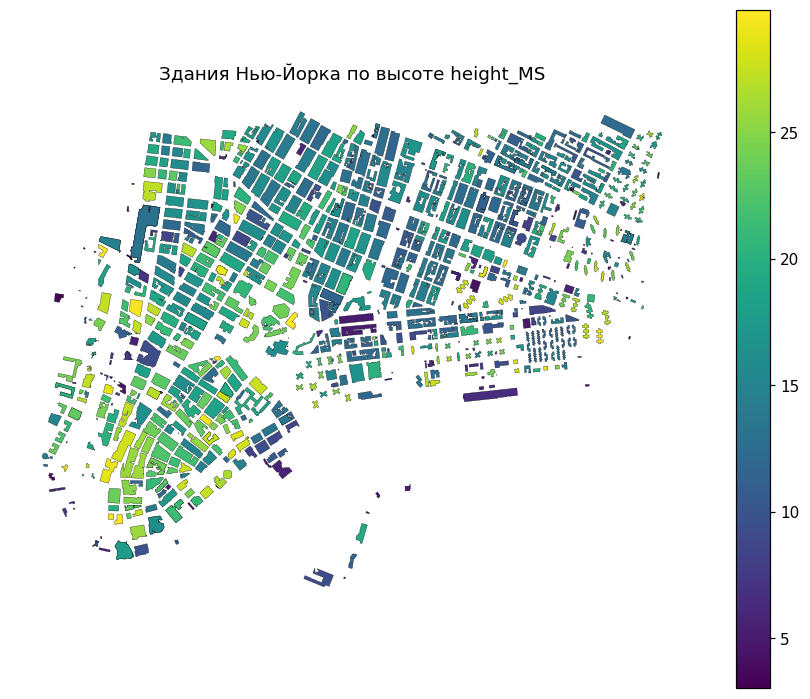

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
buildings.plot(column="height_MS", cmap="viridis", legend=True,
               edgecolor="black", linewidth=0.2, ax=ax)
ax.set_title("Здания Нью-Йорка по высоте height_MS")
ax.set_axis_off()
plt.show()

3. Создайте интерактивную карту контуров зданий и раскрасьте их в зависимости от высоты здания (используйте столбец `height_MS`).


In [12]:
buildings.explore(column="height_MS", cmap="viridis", legend=True,
                  tooltip=["height_MS"], style_kwds={"weight": 0.5})

4. Рассчитайте среднюю высоту зданий (используйте столбец `height_MS`).


In [13]:
mean_height = buildings["height_MS"].mean()
print(f"Средняя высота зданий: {mean_height:.2f}")

Средняя высота зданий: 15.45


5. Выберите здания с высотой, превышающей среднюю высоту.


In [14]:
above_average = buildings[buildings["height_MS"] > mean_height].copy()
print(f"Зданий выше среднего: {len(above_average)}")
above_average.head()

Зданий выше среднего: 524


,fid,height_MS,height_FM,height_avg,SQMETERS,STATEFP,NAME,geometry
1,4,23.62,46.18,34.90,3287.84,36,New York,"POLYGON ((-74.0032 40.71654, -74.00265 40.7163..."
2,5,19.98,109.60,64.79,2011.21,36,New York,"POLYGON ((-74.01415 40.70324, -74.01342 40.703..."
3,9,18.50,18.18,18.34,3110.32,36,New York,"POLYGON ((-73.98974 40.71924, -73.98924 40.720..."
4,34,21.53,32.84,27.18,5240.89,36,New York,"POLYGON ((-74.00941 40.72351, -74.00816 40.723..."
5,38,18.84,NaN,18.84,1151.88,36,New York,"POLYGON ((-74.01574 40.70672, -74.01537 40.706..."





6. Сохраните GeoDataFrame в новый файл GeoJSON.

In [15]:
output_geojson = "nyc_buildings_above_average.geojson"
above_average.to_file(output_geojson, driver="GeoJSON")
print(f"Сохранено {len(above_average)} зданий в {output_geojson}")

Сохранено 524 зданий в nyc_buildings_above_average.geojson


## **Задание №4. Применение NumPy, Pandas и GeoPandas для обработки и анализа пространственных данных**


1. Используйте Pandas для загрузки набора данных о городах мира по следующему URL: https://github.com/opengeos/datasets/releases/download/world/world_cities.csv


In [16]:
cities = pd.read_csv(url_cities)
cities.shape

(1249, 6)

2. Отфильтруйте набор данных, чтобы включить только города с широтой между -40 и 60 (т.е. города, расположенные в Северном полушарии или вблизи экватора).


In [17]:
filtered_cities = cities[cities["latitude"].between(-40, 60)].copy()
print(f"Городов в диапазоне широт: {len(filtered_cities)}")
filtered_cities.head()

Городов в диапазоне широт: 1132


,id,name,country,latitude,longitude,population
0,1,Bombo,UGA,0.5833,32.5333,75000
1,2,Fort Portal,UGA,0.6710,30.2750,42670
2,3,Potenza,ITA,40.6420,15.7990,69060
3,4,Campobasso,ITA,41.5630,14.6560,50762
4,5,Aosta,ITA,45.7370,7.3150,34062


3. Создайте GeoDataFrame из отфильтрованного набора данных, преобразовав широту и долготу в геометрии.


In [18]:
cities_gdf = gpd.GeoDataFrame(
    filtered_cities,
    geometry=gpd.points_from_xy(filtered_cities["longitude"], filtered_cities["latitude"]),
    crs="EPSG:4326"
)
cities_gdf.head()

,id,name,country,latitude,longitude,population,geometry
0,1,Bombo,UGA,0.5833,32.5333,75000,POINT (32.5333 0.5833)
1,2,Fort Portal,UGA,0.6710,30.2750,42670,POINT (30.275 0.671)
2,3,Potenza,ITA,40.6420,15.7990,69060,POINT (15.799 40.642)
3,4,Campobasso,ITA,41.5630,14.6560,50762,POINT (14.656 41.563)
4,5,Aosta,ITA,45.7370,7.3150,34062,POINT (7.315 45.737)


4. Перепроецируйте GeoDataFrame в проекцию Меркатора (EPSG:3857).


In [19]:
cities_mercator = cities_gdf.to_crs("EPSG:3857")
print(cities_mercator.crs)
cities_mercator[["name", "geometry"]].head()

EPSG:3857


,name,geometry
0,Bombo,POINT (3621590.39 64933.781)
1,Fort Portal,POINT (3370197.584 74697.086)
2,Potenza,POINT (1758736.635 4959679.293)
3,Campobasso,POINT (1631498.457 5095742.084)
4,Aosta,POINT (814302.075 5738302.989)


5. Рассчитайте расстояние (в метрах) между каждым городом и Парижем.


In [20]:
from shapely.geometry import Point

paris = gpd.GeoSeries([Point(2.3522, 48.8566)], crs="EPSG:4326").to_crs("EPSG:3857").iloc[0]
cities_mercator["distance_to_paris_m"] = cities_mercator.geometry.distance(paris)
cities_mercator[["name", "distance_to_paris_m"]].head()

,name,distance_to_paris_m
0,Bombo,7.039170e+06
1,Fort Portal,6.913985e+06
2,Potenza,1.976630e+06
3,Campobasso,1.791525e+06
4,Aosta,7.534054e+05


**Замечание.** Расстояния выше получены как длины прямых в EPSG:3857, как требует задание. Проекция Меркатора искажает масштаб, особенно на больших широтах, поэтому эти числа не являются точными расстояниями по поверхности Земли.



6. Отобразите города на карте мира, раскрасив точки в зависимости от их расстояния до Парижа.



> 💡 **Подсказка:** Вы можете использовать интерактивную карту `leafmap.Map()` и метод m.add_data(), передав в него ваш GeoDataFrame (предварительно возвращенный в систему координат EPSG:4326).

Основные параметры данного метода:


* column — столбец с рассчитанным расстоянием до Парижа (предварительно разделите значение расстояния на 1000, чтобы легенда отображалась в километрах).
* cmap — цветовая палитра (например, "plasma", "viridis" или "YlOrRd").
* k — количество цветовых интервалов (рекомендуется 10–15 для плавности).
* scheme — алгоритм классификации данных:
  * "Quantiles" (Квантили) — делит города на группы с равным количеством точек в каждой. Это создаст максимальный цветовой контраст: даже если города расположены кучно, вы увидите разницу между ними.
   * "EqualInterval" (Равные интервалы) — делит весь диапазон расстояний на равные отрезки в километрах (например, 0-1000 км, 1000-2000 км и т.д.). Это нагляднее показывает реальный масштаб удаленности.



* установите параметр add_legend=True, чтобы на карте появилась шкала соответствия цветов и расстояний.

In [21]:
import leafmap.foliumap as leafmap

map_cities = cities_mercator.to_crs("EPSG:4326").copy()
map_cities["distance_to_paris_km"] = map_cities["distance_to_paris_m"] / 1000
m = leafmap.Map(center=[20, 0], zoom=2)
m.add_data(map_cities[["name", "country", "distance_to_paris_km", "geometry"]],
           column="distance_to_paris_km", cmap="plasma", k=10,
           scheme="Quantiles", add_legend=True,
           legend_title="Расстояние до Парижа (км)", layer_name="Города")
m